In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import random
import torch
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plot

from torchvision import datasets
from torchvision.models import resnet152, ResNet152_Weights
from torch.utils.data import DataLoader, random_split

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device: ", device)

if torch.cuda.is_available():
    print("GPU: ", torch.cuda.get_device_name(0))


Device:  cuda
GPU:  Tesla T4


In [4]:
weights = ResNet152_Weights.DEFAULT

transform = weights.transforms()

DATA_PATH = "/content/drive/MyDrive/ATML/data"

full_train_dataset = datasets.CIFAR10(
    root=DATA_PATH,
    train=True,
    download=False,
    transform=transform
)

classes = full_train_dataset.classes

train_size = int(0.8 * len(full_train_dataset))
validation_size = len(full_train_dataset) - train_size

split_generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [train_size, validation_size],
    generator=split_generator
)

BATCH_SIZE = 32

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Classes:", classes)

Training samples: 40000
Validation samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
model = resnet152(
    weights=weights
)

model = model.to(device)

model.eval()

print("ResNet-152 loaded successfully.")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 175MB/s]


ResNet-152 loaded successfully.


In [6]:
features = {
                "early": [],
                "middle": [],
                "late": []
            }

In [7]:
def get_features(name):

    def hook(model, input, output):
        pooled_output = F.adaptive_avg_pool2d(output.detach(), output_size=(1,1))
        pooled_output = pooled_output.flatten(1)

        features[name].append(pooled_output.cpu())

    return hook

In [8]:
early_hook = model.layer1.register_forward_hook(get_features("early"))
middle_hook = model.layer3.register_forward_hook(get_features("middle"))
late_hook = model.layer4.register_forward_hook(get_features("late"))

In [9]:
model.eval()

MAX_SAMPLES = 2000
sample_collected = 0
all_labels = []

with torch.no_grad():
    for images, labels in validation_loader:
        remaining = MAX_SAMPLES - sample_collected

        if remaining <= 0:
            break

        if images.size(0) > remaining:
            images = images[:remaining]
            labels = labels[:remaining]

        images = images.to(device)

        _ = model(images)
        all_labels.append(labels.cpu())

        sample_collected += images.size(0)

    print("Samples Collected: ", sample_collected)

Samples Collected:  2000


In [10]:
early_hook.remove()
middle_hook.remove()
late_hook.remove()

In [11]:
early_features = torch.cat(features["early"], dim=0).numpy()
middle_features = torch.cat(features["middle"], dim=0).numpy()
late_features = torch.cat(features["late"], dim=0).numpy()

all_labels = torch.cat(all_labels, dim=0).numpy()

In [12]:
print("Labels:", all_labels.shape)

print("Early features :", early_features.shape)
print("Middle features:", middle_features.shape)
print("Late features  :", late_features.shape)

Labels: (2000,)
Early features : (2000, 256)
Middle features: (2000, 1024)
Late features  : (2000, 2048)


In [13]:
def apply_pca(feature_matrix):

    pca = PCA(
        n_components=50,
        random_state=SEED
    )

    reduced_features = pca.fit_transform(feature_matrix)

    return reduced_features

In [14]:
early_pca = apply_pca(early_features)
middle_pca = apply_pca(middle_features)
late_pca = apply_pca(late_features)

print("Early PCA :", early_pca.shape)
print("Middle PCA:", middle_pca.shape)
print("Late PCA  :", late_pca.shape)

Early PCA : (2000, 50)
Middle PCA: (2000, 50)
Late PCA  : (2000, 50)


In [15]:
def apply_tsne(feature_matrix):

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        max_iter=1000,
        init="pca",
        random_state=SEED
    )

    embedded_features = tsne.fit_transform(feature_matrix)

    return embedded_features

In [16]:
print("Running t-SNE on early features...")
early_tsne = apply_tsne(early_pca)

print("Running t-SNE on middle features...")
middle_tsne = apply_tsne(middle_pca)

print("Running t-SNE on late features...")
late_tsne = apply_tsne(late_pca)

print("Done!")

Running t-SNE on early features...
Running t-SNE on middle features...
Running t-SNE on late features...
Done!


In [17]:
def plot_tsne(embedding, labels, title):

    plot.figure(figsize=(10, 8))

    scatter = plot.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="tab10",
        s=15,
        alpha=0.7
    )

    colorbar = plot.colorbar(
        scatter,
        ticks=range(len(classes))
    )

    colorbar.ax.set_yticklabels(classes)

    plot.xlabel("t-SNE Dimension 1")
    plot.ylabel("t-SNE Dimension 2")

    plot.title(title)

    plot.show()

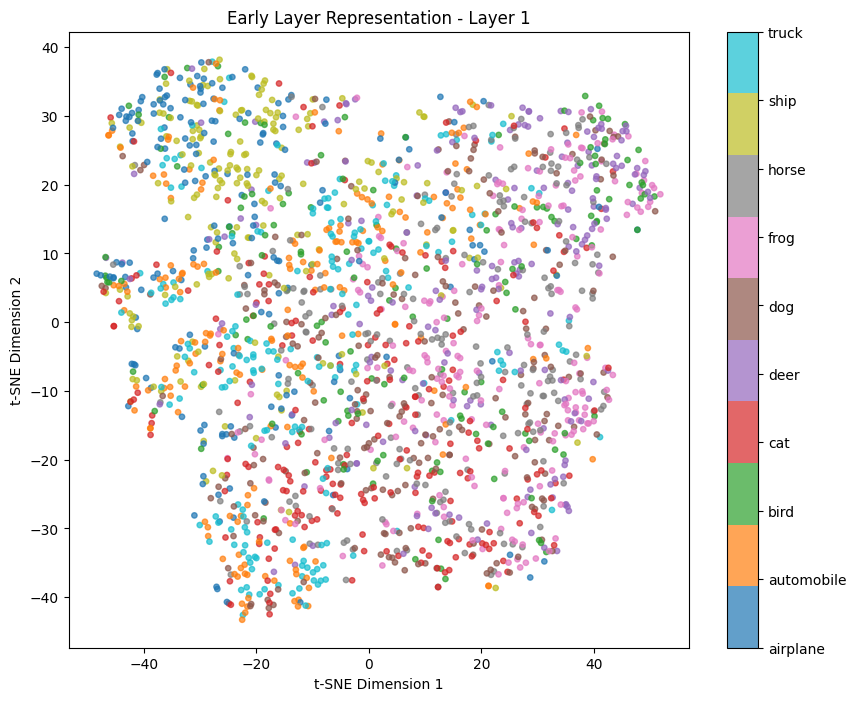

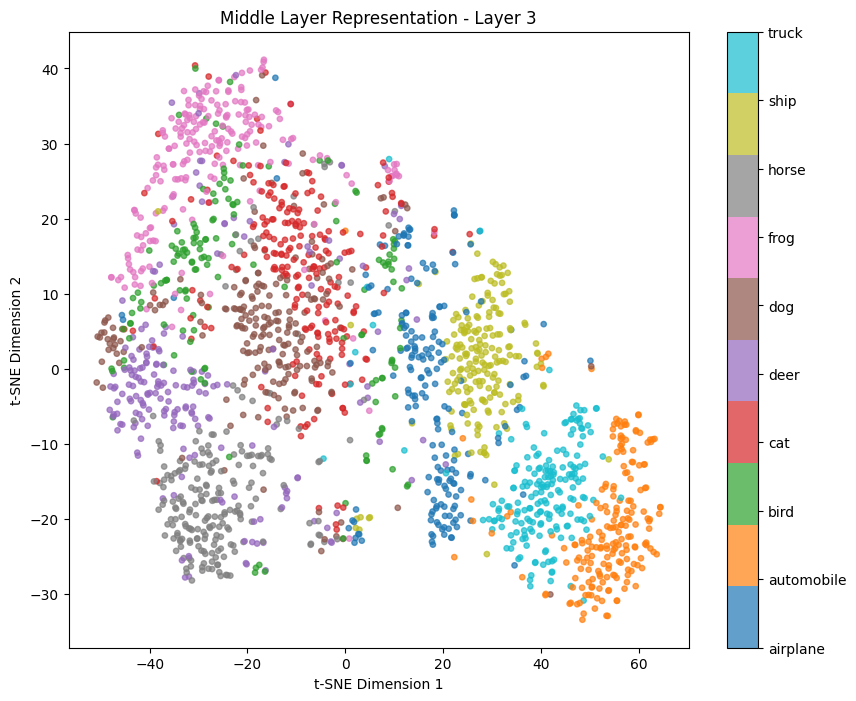

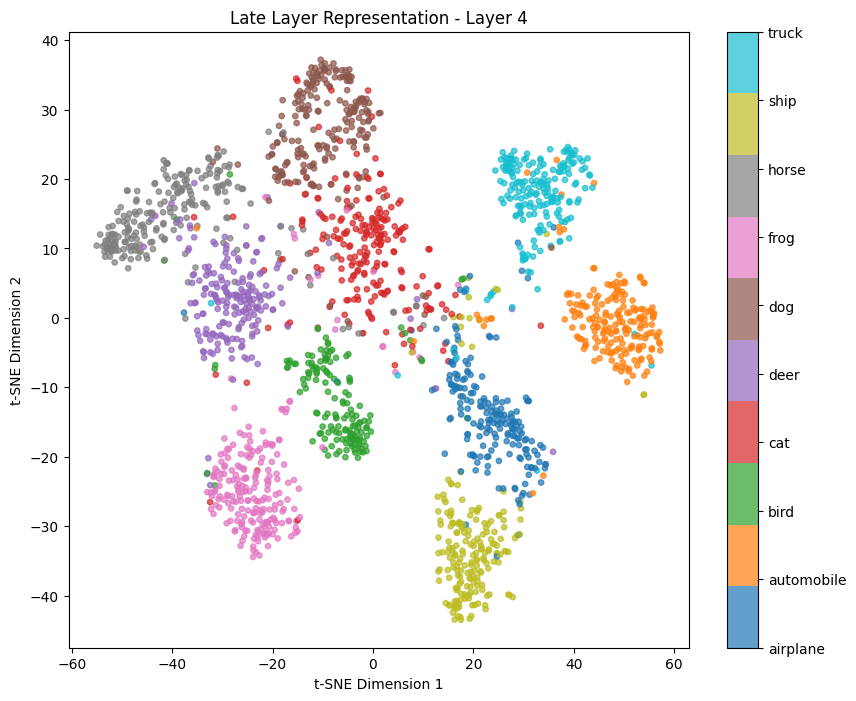

In [18]:
plot_tsne( early_tsne,all_labels, "Early Layer Representation - Layer 1" )
plot_tsne( middle_tsne, all_labels, "Middle Layer Representation - Layer 3")
plot_tsne( late_tsne, all_labels, "Late Layer Representation - Layer 4" )